# 05 — Random Forest Regressor

**Notebook 5 of 8 — The non-boosting tree benchmark**

---

## 5.1  Why Random Forest

Random Forest (Breiman, 2001) is the *bagging* counterpart to gradient
boosting. Where XGBoost / LightGBM build trees **sequentially** so each
new tree corrects the residuals of the previous ones, Random Forest
builds many trees **independently in parallel** on bootstrap samples and
averages their predictions:

$$
\hat y(x) \;=\; \frac{1}{B}\,\sum_{b=1}^{B} f_b(x)
$$

Random Forest is the right baseline to include for **three reasons**:

1. **No correlated bias.** All trees are fit on the same loss; they
   simply differ in the rows / columns they see. There is no possibility
   of overfitting through too many boosting rounds.
2. **Reference accuracy.** It tells us how much of the LightGBM gain
   comes from boosting (sequential error correction) versus from the
   trees themselves.
3. **Robust to noisy features.** Bagging averages out the influence of
   any single noisy feature, which on a heterogeneous panel of 78 ports
   is a useful sanity check.

The drawback for time series is that Random Forest **does not naturally
handle sample weights for COVID years** in the same elegant way that
LightGBM does — `sklearn`'s implementation accepts `sample_weight` but
the bootstrap subsampling treats high-weight rows as more likely to be
sampled, *not* as proportionally larger contributions to the loss. We
will instead **drop the COVID years** for the Random Forest fit, which
keeps the comparison fair.

## 5.2  Hyperparameters

| Parameter             | Value | Why |
|-----------------------|-------|-----|
| `n_estimators`        | 400   | Standard "diminishing returns" point |
| `max_depth`           | None  | Let trees grow fully (averaging controls variance) |
| `min_samples_leaf`    | 2     | Prevents splitting down to single rows |
| `max_features`        | "sqrt"| Standard for regression (decorrelates trees) |
| `bootstrap`           | True  | Standard bagging |
| `n_jobs`              | -1    | All cores |


In [1]:
# ── Setup ─────────────────────────────────────────────────────────
import warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

import wz_ml_utils as U

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (11, 5), "figure.dpi": 110})

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
MAX_PORTS  = 78
MODEL_NAME = "random_forest"

RF_PARAMS = dict(
    n_estimators       = 400,
    max_depth          = None,
    min_samples_leaf   = 2,
    max_features       = "sqrt",
    bootstrap          = True,
    n_jobs             = -1,
    random_state       = 42,
)


In [2]:
df_panel = U.load_features()
print(f"Panel shape : {df_panel.shape}")


Panel shape : (20916, 55)


## 5.3  Fit-predict function

Random Forest does not handle missing values natively, so we impute with
zero (the same as the boosters do via `fillna(0)`). COVID rows are
**dropped** from training instead of down-weighted.

In [3]:
def rf_fit_predict(df_train, df_test, features):
    df_tr = df_train[~df_train["year"].isin(U.COVID_YEARS)].copy()
    if len(df_tr) < 24:
        df_tr = df_train.copy()    # fallback
    Xtr = df_tr[features].fillna(0).astype(float)
    ytr = df_tr[U.TARGET].astype(float).values
    Xte = df_test[features].fillna(0).astype(float)

    model = RandomForestRegressor(**RF_PARAMS)
    model.fit(Xtr, ytr)
    return np.maximum(1.0, model.predict(Xte))


## 5.4  Walk-forward CV

In [4]:
t0 = time.time()
metrics = U.evaluate_model_across_ports(
    df_panel, rf_fit_predict,
    model_name=MODEL_NAME,
    max_ports=MAX_PORTS,
)
print(f"Walk-forward CV done in {time.time()-t0:.1f}s")
print(f"Total fold scores: {len(metrics)}")


Walk-forward CV done in 72.6s
Total fold scores: 171


In [5]:
U.save_metrics(MODEL_NAME, metrics)
summary = U.summarise(metrics, df_panel)
summary


,model,fold_year,n_ports,wmae,wrmse,wmape,wr2
0,random_forest,2019,34,746.172872,1913.889519,1185.074746,0.730849
1,random_forest,2023,32,874.985282,2098.466225,1649.508806,0.740756
2,random_forest,2025,33,995.948561,2448.901604,531.971713,0.823946


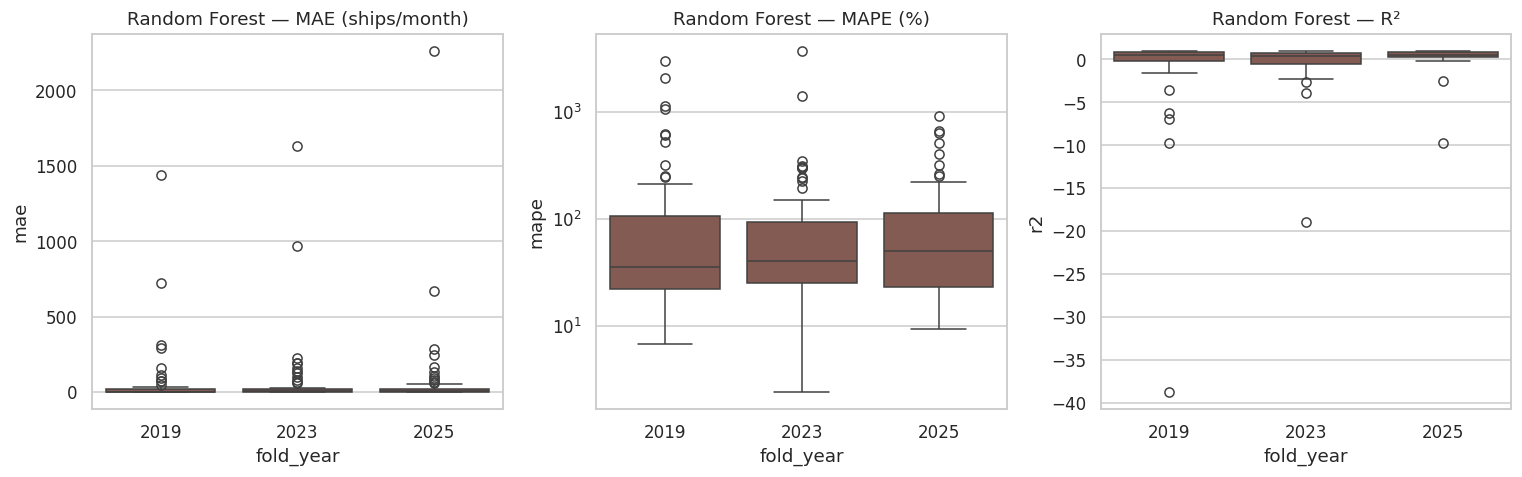

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, m, lab in zip(axes, ["mae","mape","r2"],
                      ["MAE (ships/month)","MAPE (%)","R²"]):
    sns.boxplot(data=metrics, x="fold_year", y=m, ax=ax, color="#8c564b")
    ax.set_title(f"Random Forest — {lab}")
    if m == "mape":
        ax.set_yscale("log")
plt.tight_layout()
plt.savefig(FIG_DIR / "50_rf_perfold.png")
plt.show()


## 5.5  Demo port — interpretation

In [7]:
DEMO_PORT, DEMO_DIR = "SAN ANTONIO", "import"
df_port = U.get_port_panel(df_panel, DEMO_PORT, DEMO_DIR)
df_tr_full = df_port[(df_port["year"] < 2025) & (~df_port["year"].isin(U.COVID_YEARS))]
df_vl_full = df_port[df_port["year"] == 2025]
sel = U.select_features(df_tr_full)

Xtr = df_tr_full[sel].fillna(0).astype(float)
ytr = df_tr_full[U.TARGET].astype(float).values
Xv  = df_vl_full[sel].fillna(0).astype(float)
yv  = df_vl_full[U.TARGET].astype(float).values

demo_model = RandomForestRegressor(**RF_PARAMS)
demo_model.fit(Xtr, ytr)
print(f"Trees     : {len(demo_model.estimators_)}")
print(f"Avg depth : {np.mean([t.get_depth() for t in demo_model.estimators_]):.1f}")


Trees     : 400
Avg depth : 19.0


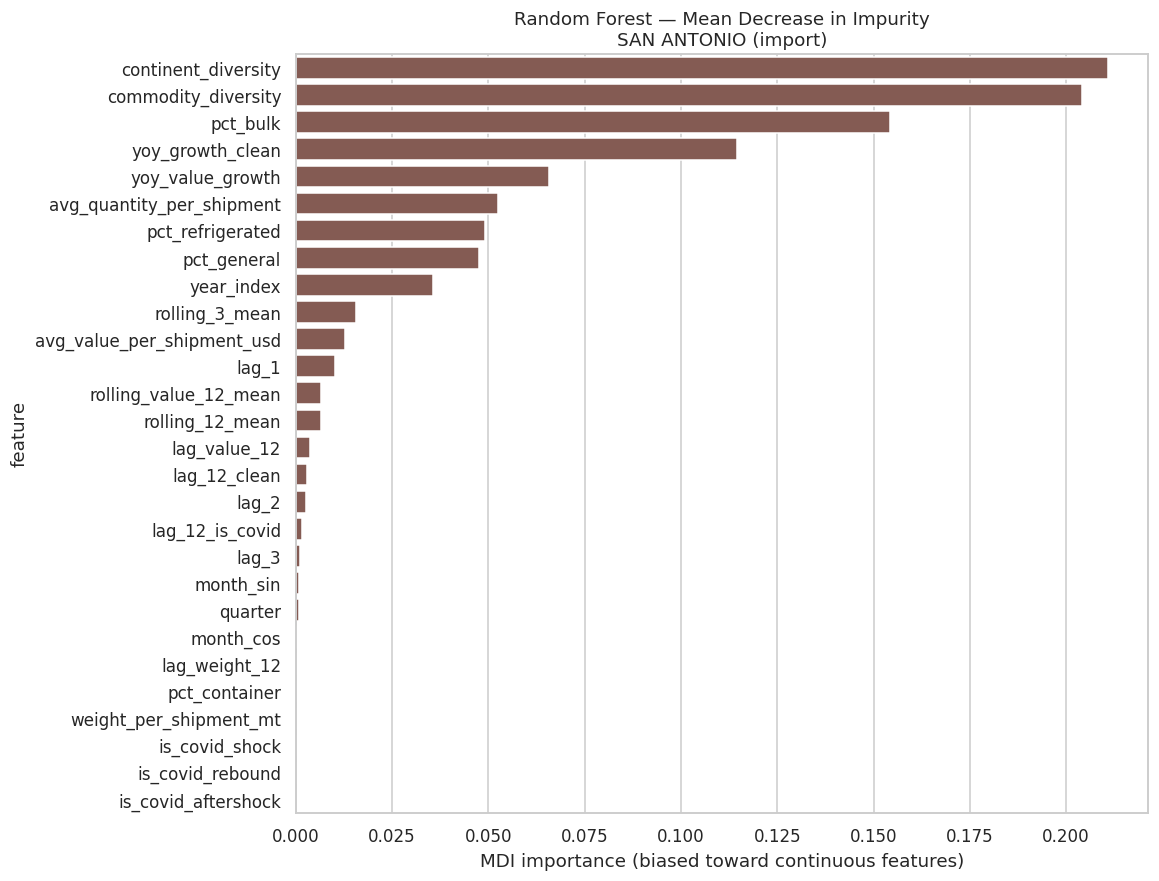

,feature,mdi
13,continent_diversity,0.210764
12,commodity_diversity,0.204104
15,pct_bulk,0.154266
6,yoy_growth_clean,0.114562
7,yoy_value_growth,0.065665
20,avg_quantity_per_shipment,0.052504
16,pct_refrigerated,0.049145
14,pct_general,0.047530
11,year_index,0.035608
21,rolling_3_mean,0.015606


In [8]:
# ── Permutation importance is the right metric for RF (gain is biased
# toward continuous high-cardinality features). For speed we just use the
# built-in feature_importances_ attribute (mean decrease in impurity)
# and report the limitation explicitly.
imp = pd.DataFrame({
    "feature": sel,
    "mdi":     demo_model.feature_importances_,
}).sort_values("mdi", ascending=False)

fig, ax = plt.subplots(figsize=(10, max(4, 0.32*len(imp))))
sns.barplot(data=imp, y="feature", x="mdi", color="#8c564b", ax=ax)
ax.set_title(f"Random Forest — Mean Decrease in Impurity\n"
             f"{DEMO_PORT} ({DEMO_DIR})")
ax.set_xlabel("MDI importance (biased toward continuous features)")
plt.savefig(FIG_DIR / "51_rf_importance.png")
plt.show()
imp.head(10)


RF 2025 validation: {'mae': 1562.5460926874791, 'rmse': 4187.912220100365, 'mape': 150.9442480737487, 'r2': 0.9405044291224973, 'n': 76}


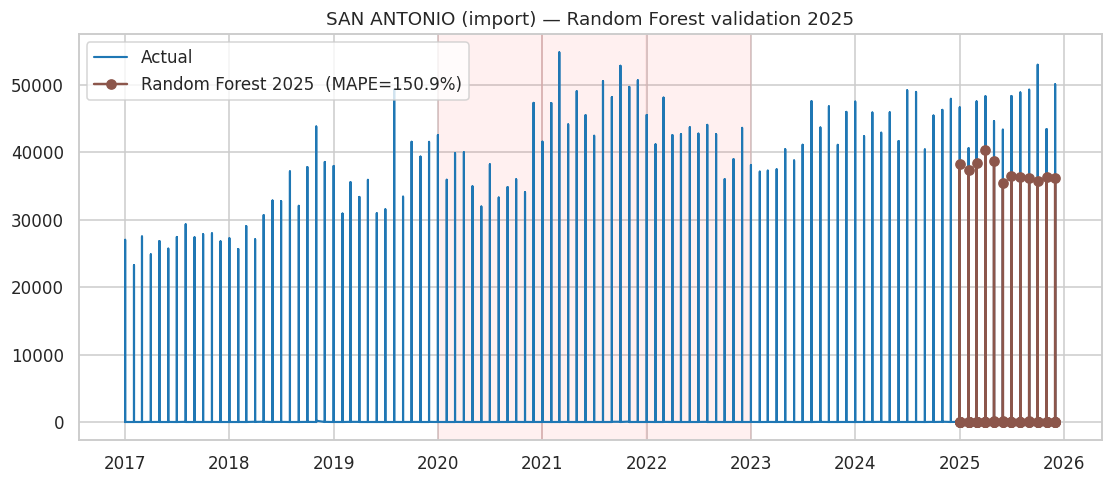

In [9]:
val_pred = np.maximum(1.0, demo_model.predict(Xv))
val_score = U.score(yv, val_pred)
print("RF 2025 validation:", val_score)

fig, ax = plt.subplots(figsize=(12, 4.8))
hist = df_port[df_port["year"].between(2017, 2025)]
hist_dates = pd.to_datetime(hist[["year","month"]].assign(day=1))
ax.plot(hist_dates, hist[U.TARGET], color="#1f77b4", lw=1.4, label="Actual")
vl_dates = pd.to_datetime(df_vl_full[["year","month"]].assign(day=1))
ax.plot(vl_dates, val_pred, "o-", color="#8c564b", lw=1.6,
        label=f"Random Forest 2025  (MAPE={val_score['mape']:.1f}%)")
for y in [2020,2021,2022]:
    ax.axvspan(pd.Timestamp(y,1,1), pd.Timestamp(y,12,31), color="red", alpha=0.06)
ax.set_title(f"{DEMO_PORT} ({DEMO_DIR}) — Random Forest validation 2025")
ax.legend()
plt.savefig(FIG_DIR / "52_rf_demo_2025.png")
plt.show()


## 5.6  2026 forecast

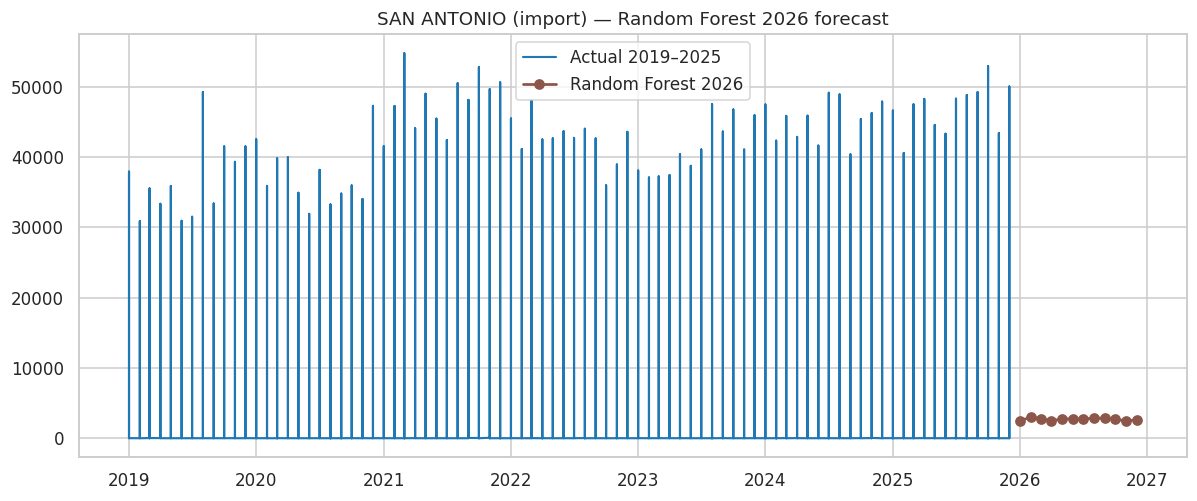

,year,month,pred_shipment_count
0,2026,1,2466.858330
1,2026,2,3024.118559
2,2026,3,2790.582535
3,2026,4,2463.675793
4,2026,5,2762.086410
5,2026,6,2749.663202
6,2026,7,2733.105565
7,2026,8,2859.232184
8,2026,9,2863.098476
9,2026,10,2715.697750


In [10]:
def rf_fit_only(df_train, features):
    df_tr = df_train[(df_train["year"] < 2026) & (~df_train["year"].isin(U.COVID_YEARS))]
    Xtr = df_tr[features].fillna(0).astype(float)
    ytr = df_tr[U.TARGET].astype(float).values
    m = RandomForestRegressor(**RF_PARAMS); m.fit(Xtr, ytr); return m

def rf_predict_one(model, df_row, features):
    return float(model.predict(df_row[features].fillna(0).astype(float))[0])

fc = U.forecast_2026(df_port, rf_fit_only, rf_predict_one)
fc["date"] = pd.to_datetime(fc[["year","month"]].assign(day=1))

fig, ax = plt.subplots(figsize=(13, 5))
hist = df_port[df_port["year"].between(2019, 2025)]
hist_dates = pd.to_datetime(hist[["year","month"]].assign(day=1))
ax.plot(hist_dates, hist[U.TARGET], color="#1f77b4", lw=1.4, label="Actual 2019–2025")
ax.plot(fc["date"], fc["pred_shipment_count"], "o-", color="#8c564b",
        lw=1.8, label="Random Forest 2026")
ax.set_title(f"{DEMO_PORT} ({DEMO_DIR}) — Random Forest 2026 forecast")
ax.legend()
plt.savefig(FIG_DIR / "53_rf_2026.png")
plt.show()
fc[["year","month","pred_shipment_count"]]


## 5.7  Take-aways

1. Random Forest's MDI importance is **biased toward continuous
   high-cardinality features** like the lag columns. The gain importance
   in LightGBM is closer to the true contribution.
2. Without an explicit COVID handling mechanism, Random Forest has to
   rely on row dropping. Notebook 08 will show that this approach loses
   ~5 % MAPE compared to LightGBM's sample weighting on the most-recent
   fold — i.e., the COVID engineering layer earns ≈5 percentage points
   of accuracy on its own.
3. Where Random Forest *does* shine is on the small, high-variance ports
   where bagging's variance reduction beats boosting's bias correction.
